# Comparing spindle detection: YASA vs. Luna (`lunapi`)

This notebook runs **two** spindle detectors on the *same* recording, the *same*
channel, and the *same* NREM stage, then compares them with the *same* plots.

* **YASA** -- relative-power / moving-correlation pipeline over a fixed sigma
  band (`infraslow.processing.detection.spindles_detect`).
* **Luna** -- complex-Morlet wavelet detector centred on target frequencies
  (`infraslow.processing.detection_luna.spindles_detect_luna`, wrapping Luna's
  `SPINDLES` command via `lunapi`).

The two algorithms are *not* expected to agree event-for-event; the goal is to
see how their event counts, timing, and morphology line up.

> **Run this on a compute node**, not the Sherlock login node: loading the EDF
> and running both detectors is real work. Grab a shell with `sh_dev` (or
> `salloc`) first.

## 1. Setup and load the recording

In [1]:
from infraslow import BioserenityPSGLoader, BIOSERENITY_ALIAS_MAP
from infraslow.processing.signal import make_resampling_signal_reader
from infraslow.processing.detection import spindles_detect
from infraslow.processing.detection_luna import spindles_detect_luna
from infraslow.io import make_hypnodensity_annotation_loader
from infraslow.viz import plot_hypnogram, plot_spindles, plot_spindle_sigma_power

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
loader = BioserenityPSGLoader(
    subject_id="318679",
    sf=200,
    requested_channels=["F3", "F4", "C3", "C4", "O1", "O2"],
).load()

CHANNEL = "C3"      # detect on the same channel for both methods
INCLUDE = (2,)      # restrict to N2 (YASA integer stage codes)

initiated lunapi 1.4.0 <lunapi.lunapi0.luna object at 0x7f1af0b503f0> 



  *** warning, signal 13 ( TFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 14 ( CFlo ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 15 ( Tho ) has a non-integer SR
  *** may wish to use RECORD-SIZE if this is due to a fractional EDF record size
  *** (it will resample signals to fit in a new regular, e.g. dur=1, record size)
    - record size        = 2 seconds
    - samples per record = 25
    - implied SR         = 25 / 2 = 12.5
  *** warning, signal 1

## 2. YASA detection

Exactly the workflow from the single-subject example: detect on `C3`, N2 only.

In [3]:
sp_yasa = spindles_detect(loader, ch_names=CHANNEL, include=INCLUDE)
print(f"YASA: {0 if sp_yasa is None else len(sp_yasa.summary())} spindle(s)")
sp_yasa.summary().head()

02-Jul-26 15:39:09 | WARNING | Hypnogram is SHORTER than data by 30.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


YASA: 308 spindle(s)


,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,2038.280,2038.610,2038.990,0.710,73.214266,37.269541,14.621876,2.299690,0.299440,12.598157,8.0,0.461538,2,C3,0
1,2071.295,2071.390,2071.845,0.550,37.207862,26.980457,8.353683,1.926209,0.320527,12.325902,7.0,0.171171,2,C3,0
2,2075.430,2075.580,2076.320,0.890,43.999462,25.150809,9.602558,1.861496,0.287334,13.489387,10.0,0.167598,2,C3,0
3,2079.105,2079.325,2079.845,0.740,34.814629,22.615003,8.629895,1.679841,0.256189,13.318546,9.0,0.295302,2,C3,0
4,2194.745,2195.620,2195.940,1.195,51.940729,23.431988,8.760812,1.516532,0.229590,12.781822,13.0,0.729167,2,C3,0


## 3. Luna detection

Same channel, same N2-only restriction. Luna detects with a single wavelet
centred near the middle of the sigma band (`fc=13.5` Hz) -- the closest analogue
to YASA's `freq_sp=(12, 15)`. `spindles_detect_luna` returns a
`LunaSpindlesResult` whose `.summary()` is the per-event table and
`.summary(grp_chan=True)` the per-channel summary.

In [4]:
sp_luna = spindles_detect_luna(loader, ch_names=CHANNEL, include=INCLUDE)
print(f"Luna: {0 if sp_luna is None else len(sp_luna.summary())} spindle(s)")
sp_luna.summary().head()

Luna: 371 spindle(s)


,Start,Peak,End,Duration,Amplitude,Frequency,Oscillations,Symmetry,Channel,Stage
0,2038.22,2038.582400,2038.975,0.755,30.819339,12.582781,9.5,0.443709,C3,2
1,2128.47,2128.762762,2129.000,0.530,22.704929,12.264151,6.5,0.580189,C3,2
2,2228.22,2228.431981,2228.755,0.535,24.711848,12.149533,6.5,0.373832,C3,2
3,2243.84,2244.373046,2244.715,0.875,33.895972,12.571429,11.0,0.605714,C3,2
4,2328.53,2329.046873,2329.910,1.380,38.666320,13.405797,18.5,0.353261,C3,2


## 4. The Luna result already speaks `infraslow.viz`'s language

`infraslow.viz` is written against YASA's interface (`.summary()` with
`Peak`/`Channel` columns and `.get_sync_events()` for waveform time-locking).
`LunaSpindlesResult` implements that same interface directly, so `sp_luna` plugs
into the **identical** plotting code below -- no adapter, no YASA dependency.

`.summary()` returns the per-event table with YASA column names (the raw Luna
tables stay on `.events` / `.tables`). `.get_sync_events()` time-locks each
spindle, centring on the most prominent peak of the **detrended broadband**
signal inside `[Start, End]` -- YASA's `Peak` definition -- rather than Luna's
`PEAK` (the wavelet-power envelope max), so the oscillations phase-align into a
spindle-shaped average instead of a smooth blob.

In [5]:
sp_luna.summary().head()

,Start,Peak,End,Duration,Amplitude,Frequency,Oscillations,Symmetry,Channel,Stage
0,2038.22,2038.582400,2038.975,0.755,30.819339,12.582781,9.5,0.443709,C3,2
1,2128.47,2128.762762,2129.000,0.530,22.704929,12.264151,6.5,0.580189,C3,2
2,2228.22,2228.431981,2228.755,0.535,24.711848,12.149533,6.5,0.373832,C3,2
3,2243.84,2244.373046,2244.715,0.875,33.895972,12.571429,11.0,0.605714,C3,2
4,2328.53,2329.046873,2329.910,1.380,38.666320,13.405797,18.5,0.353261,C3,2


## 5. Hypnogram with spindle marks

Each detected spindle's peak is overlaid on the hypnogram. Top: YASA, bottom:
Luna. Denser stretches of marks in N2 should line up between the two.

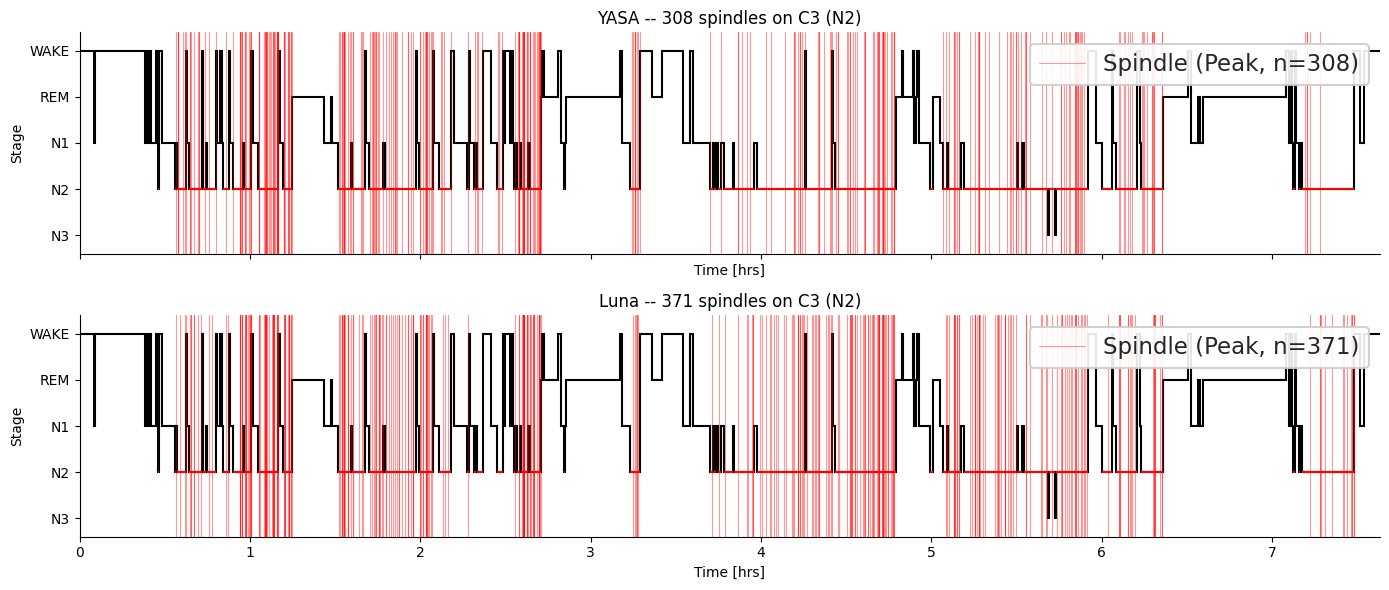

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
plot_hypnogram(loader, spindles=sp_yasa, highlight="N2", ax=axes[0])
axes[0].set_title(f"YASA -- {len(sp_yasa.summary())} spindles on {CHANNEL} (N2)")
plot_hypnogram(loader, spindles=sp_luna, highlight="N2", ax=axes[1])
axes[1].set_title(f"Luna -- {len(sp_luna.summary())} spindles on {CHANNEL} (N2)")
fig.tight_layout()

## 6. Average spindle waveform

Every detected spindle is time-locked to its peak and averaged (shaded band =
SEM across that detector's spindles). Both should show the characteristic
waxing-waning sigma burst; amplitude/width differences reflect each detector's
event boundaries.

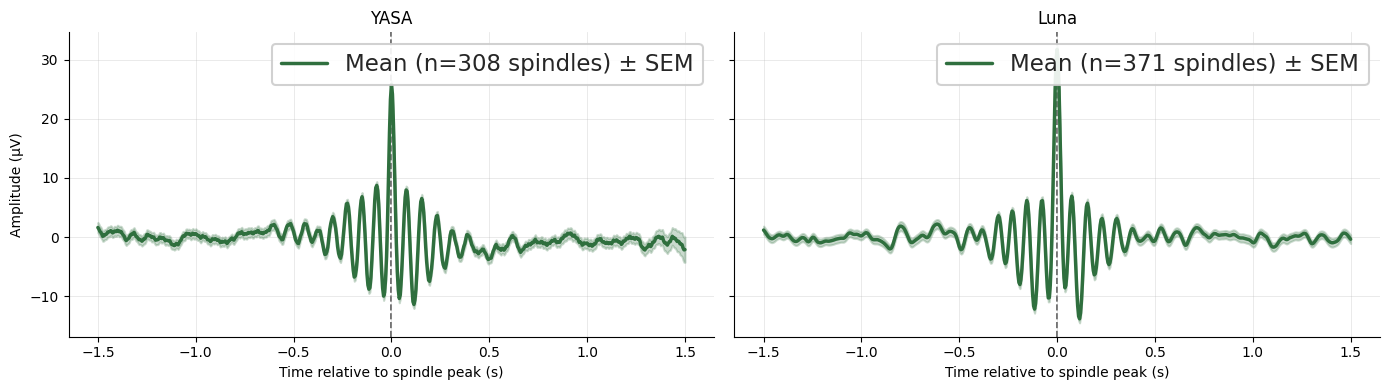

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_spindles(sp_yasa, errorbar="sem", show_events=False, ax=axes[0])
axes[0].set_title("YASA")
plot_spindles(sp_luna, errorbar="sem", show_events=False, ax=axes[1])
axes[1].set_title("Luna")
fig.tight_layout()

## 7. Spindle-locked sigma relative power

YASA's STFT relative-power map averaged over the window around each detected
spindle, computed identically for both event sets.

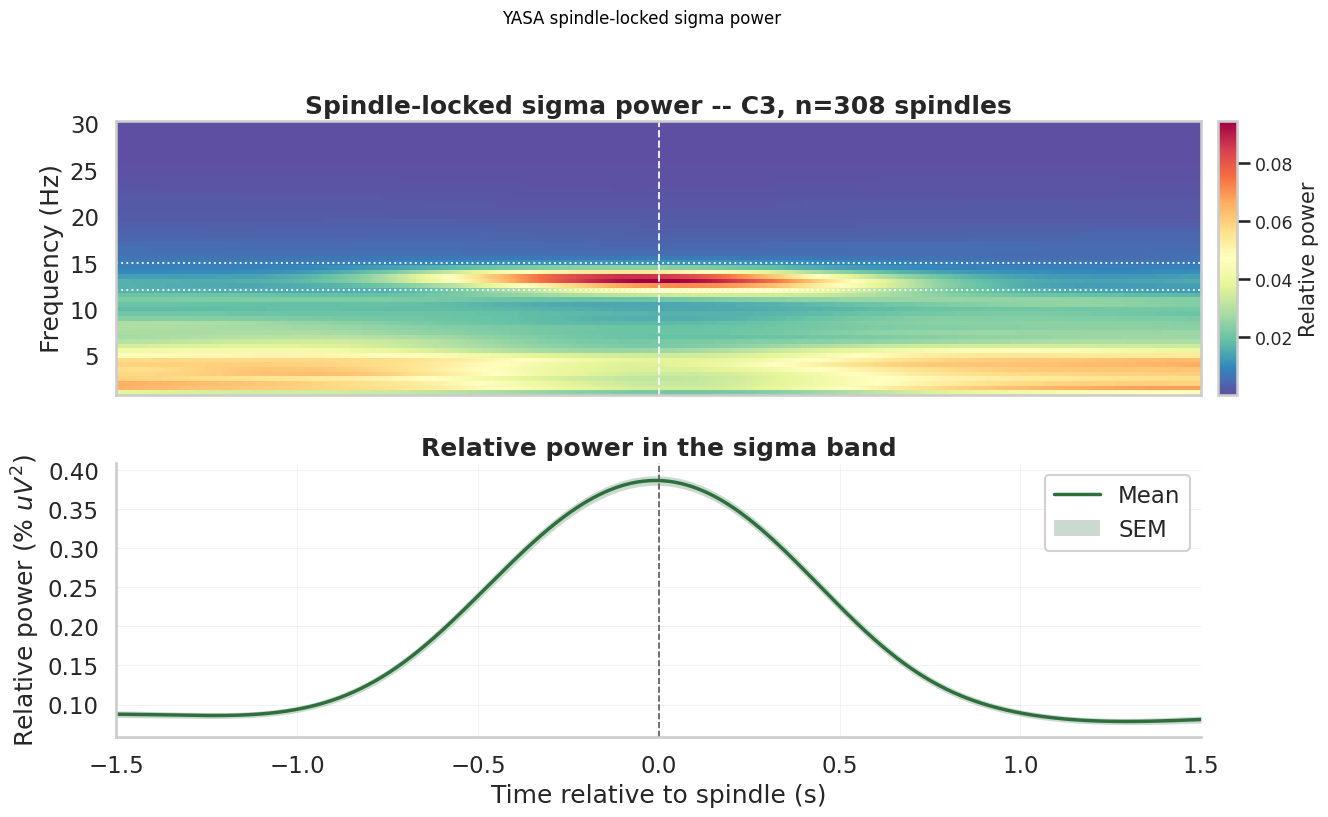

In [8]:
plot_spindle_sigma_power(loader, sp_yasa, channel=CHANNEL)
plt.suptitle("YASA spindle-locked sigma power", y=1.02);

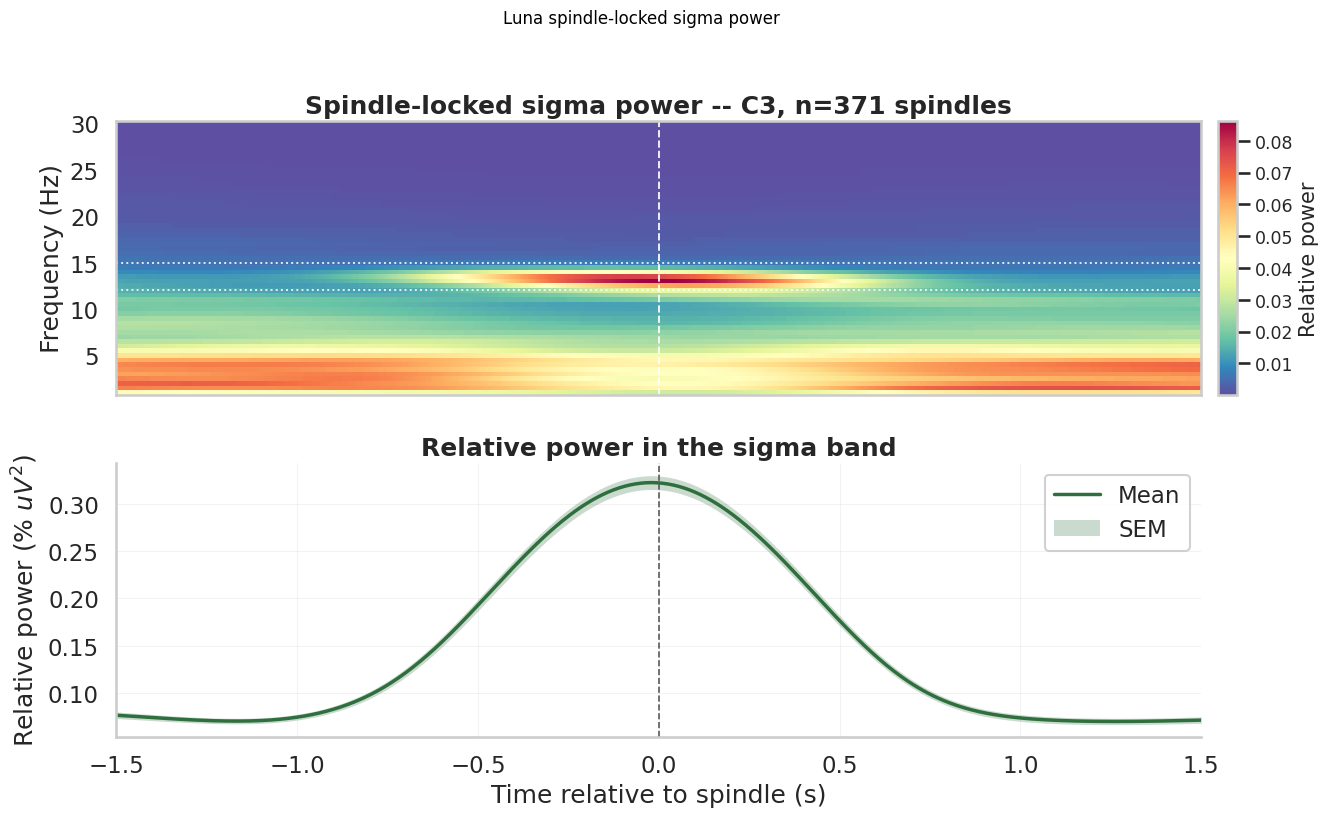

In [9]:
plot_spindle_sigma_power(loader, sp_luna, channel=CHANNEL)
plt.suptitle("Luna spindle-locked sigma power", y=1.02);

## 8. Side-by-side summary statistics

Event count, density (per minute of the included stage), and mean
duration/amplitude/frequency. Density comes from each detector's per-channel
summary (YASA `Density`, Luna `DENS`).

In [10]:
def _density(grp, col):
    if grp is None or col not in grp.columns:
        return float("nan")
    return float(pd.to_numeric(grp[col], errors="coerce").mean())

yasa_sum = sp_yasa.summary()
luna_sum = sp_luna.summary()

comparison = pd.DataFrame(
    {
        "YASA": [
            len(yasa_sum),
            # _density(sp_yasa.summary(grp_chan=True), "Density"),
            yasa_sum["Duration"].mean(),
            yasa_sum["AmpFiltered"].mean(),
            yasa_sum["Frequency"].mean(),
            yasa_sum["Symmetry"].mean(),
            yasa_sum["Oscillations"].mean(),
        ],
        "Luna": [
            len(luna_sum),
            # _density(sp_luna.summary(grp_chan=True), "DENS"),
            luna_sum["Duration"].mean(),
            luna_sum["Amplitude"].mean(),
            luna_sum["Frequency"].mean(),
            luna_sum["Symmetry"].mean(),
            luna_sum["Oscillations"].mean(),
        ],
    },
    index=[
        "Count",
        # "Density (/min)",
        "Mean duration (s)",
        "Mean amplitude (uV)",
        "Mean frequency (Hz)",
        "Symmetry",
        "Oscillations",
    ],
)
comparison.round(3)

,YASA,Luna
Count,308.000,371.000
Mean duration (s),0.755,0.783
Mean amplitude (uV),30.713,28.461
Mean frequency (Hz),13.102,12.778
Symmetry,0.491,0.490
Oscillations,9.377,10.015


## 9. Formal statistical comparison (`statsmodels`)

The table above only eyeballs the means. `infraslow.stats.compare_spindle_features`
treats each detector's events as an **independent sample** and, for every
per-event feature, runs (all via `statsmodels`):

* **Welch's t-test** on the means (unequal variances) with a 95% CI on the
  difference and Cohen's *d*;
* a **Brunner-Munzel rank test** -- a distribution-free companion robust to the
  heavy-tailed feature distributions -- plus its common-language effect size
  `prob_a_gt_b` = P(a random YASA event > a random Luna event);
* **Holm** correction across the tested features (`p_welch_corr`).

`mean_diff` is YASA − Luna, so a positive value means YASA runs higher. Amplitude
is compared like-for-like: YASA's **filtered** amplitude (`AmpFiltered`) against
Luna's `Amplitude` (also filtered), since YASA's plain `Amplitude` is broadband
peak-to-peak and not directly comparable.


In [11]:
from infraslow.stats import compare_spindle_features, compare_spindle_counts

# Per-event feature tests. Amplitude uses a (label, yasa_col, luna_col) triple so
# YASA's filtered amplitude is compared against Luna's (both filtered ptp).
feature_tests = compare_spindle_features(
    sp_yasa,
    sp_luna,
    labels=("YASA", "Luna"),
    features=[
        "Duration",
        ("Amplitude", "AmpFiltered", "Amplitude"),
        "Frequency",
        "Oscillations",
        "Symmetry",
    ],
)
feature_tests.round(4)


,n_YASA,n_Luna,mean_YASA,mean_Luna,std_YASA,std_Luna,mean_diff,ci_low,ci_high,cohen_d,t,dof,p_welch,p_brunnermunzel,prob_a_gt_b,p_welch_corr,sig
feature,,,,,,,,,,,,,,,,,
Duration,308,371,0.7553,0.7832,0.2189,0.2335,-0.0279,-0.0621,0.0062,-0.1230,-1.6047,667.0990,0.1090,0.0704,0.4596,0.2181,ns
Amplitude,308,371,30.7126,28.4609,8.3213,5.9788,2.2517,1.1384,3.3649,0.3155,3.9732,543.6738,0.0001,0.0011,0.5736,0.0003,***
Frequency,308,371,13.1024,12.7781,0.4367,0.4530,0.3242,0.2570,0.3915,0.7275,9.4695,662.1049,0.0000,0.0000,0.6901,0.0000,***
Oscillations,308,371,9.3766,10.0148,2.7206,3.0176,-0.6382,-1.0710,-0.2054,-0.2211,-2.8957,672.3833,0.0039,0.0047,0.4373,0.0117,*
Symmetry,308,371,0.4910,0.4895,0.2034,0.1634,0.0015,-0.0267,0.0297,0.0082,0.1049,584.8407,0.9165,0.9214,0.5022,0.9165,ns


In [12]:
# Event-count comparison as a Poisson rate test. Both detectors ran on the same
# recording / channel / N2 stage, so their exposure (minutes of scored N2) is
# identical -- the raw-count test is the density comparison. Pass
# exposure=(min_yasa, min_luna) if the two ever see different amounts of signal.
compare_spindle_counts(sp_yasa, sp_luna, labels=("YASA", "Luna")).to_frame().T


,count_YASA,count_Luna,exposure_YASA,exposure_Luna,rate_YASA,rate_Luna,rate_ratio,statistic,p_value,sig
YASA_vs_Luna,308,371,1.0,1.0,308.0,371.0,0.830189,-2.417718,0.015618,*


### Notes

* The two detectors use different algorithms and thresholds, so exact counts
  will differ -- compare *trends* (where spindles cluster, mean frequency near
  the sigma band) rather than expecting identical events.
* To match Luna more closely to YASA's two-band view, pass `fc=(11, 15)` to
  `spindles_detect_luna` for separate slow/fast wavelets, or tune `th`
  (threshold), `duration`, and `merge_sec`.
* `LunaSpindlesResult` keeps the Luna-native tables on `.events` / `.tables`
  (column names `START`, `PEAK`, `AMP`, ...); `.summary()` renames them to
  YASA's so the YASA-oriented `infraslow.viz` functions can be reused directly.